# Hodgkin-Huxley Model
*Owen Page (2025), based on work by V Srinivasa Chakravarthy*

## Import libraries
We first need to import our required libraries. We will be using two libraries,
NumPy and MatPlotLib.

+ **NumPy** - Used for creating and manipulating high-performance 
arrays/matrices, also provides a number of mathematical functions.
+ **MatPlotLib** - Allows us to create graphs and figures from our data.

We will give NumPy the alias `np` for readability.

From MatPlotLib we will only import the module `pyplot`, giving it the alias
`plt`.

In [2]:
import numpy as np
from matplotlib import pyplot as plt

## Defining program parameters

First we will define our time-related parameters.

| Name      | Description                                | Units |
|-----------|--------------------------------------------|-------|
| `n_iter`  | The total number of iterations             | n/a   |
| `t_max`   | The final time point                       | ms    |
| `t_range` | Array containing all time steps            | n/a   |
| `dt`      | The amount time increases by per iteration | ms    |

NumPy's `linspace` function is used to generate an array of evenly spaced
numbers. The start point, end point, and number of entries are provided,
additionally an optional keyword argument `retstep` is used to return step 
between each entry.

In [3]:
# dt should be 0.01 with these values
n_iter = 10_000
t_max = 100
t_range, dt = np.linspace(0, t_max, n_iter, retstep=True)

Next we will define our *fixed* model parameters. These will be set once and not change again.

| Name           | Description                      | Unit |
|----------------|----------------------------------|------|
| `I_in`         | External input current           | nA   |
| `g_max_k`      | Potassium maximum conductance    | mS   |
| `v_eq_k`       | Potassium reversal potential     | mv   |
| `g_max_na`     | Sodium maximum conductance       | mS   |
| `v_eq_na`      | Sodium reversal potential        | mv   |
| `g_leak`       | Membrane leak conductance        | mS   |
| `v_eq_leak`    | Membrane leak reversal potential | mv   |
| `membrane_cap` | Membrane capacitance             | μF   |

In [4]:
input_current = 0.9  # Input current

g_max_k = 0.36  # Max potassium conductance
v_eq_k = -77  # Potassium reversal potential

g_max_na = 1.20  # Max sodium conductance
v_eq_na = 50  # Sodium reversal potential

g_leak = 0.003  # Leak conductance
v_eq_leak = -54.387  # Leak reversal potential

membrane_cap = 0.01  # Membrane capacitance

Next we'll declare the variable parameters, unlike the above parameters, these will change from their initial values as the model runs.

| Name | Description              | Unit |
|------|--------------------------|------|
| `v`  | Total membrane potential | mv   |
| `n`  | Potassium gate state     | n/a  |
| `m`  | Sodium *m* gate state    | n/a  |
| `h`  | Sodium *h* gate state    | n/a  |

In [5]:
v = -64.9964
n = 0.3177
m = 0.0530
h = 0.5960

Finally, we'll create some arrays to keep track of the values of our variable
parameters with respect to time. These will have a size of `n_iter`, giving
each array one element per timestep.

In [6]:
v_hist = np.empty(n_iter)
m_hist = np.empty(n_iter)
h_hist = np.empty(n_iter)
n_hist = np.empty(n_iter)

## Running the simulation

In [7]:
for i, t in enumerate(t_range):
    # Calculate the ion channel conductances based on their gate states
    na_g = g_max_na * m**3 * h
    k_g = g_max_k * n**4
    # Get the total conductance, including membrane leak
    total_g = na_g + k_g + g_leak

    v_inf = (
        (na_g * v_eq_na + k_g * v_eq_k + g_leak * v_eq_leak) + input_current
    ) / total_g

    tau_v = membrane_cap / total_g

    v = v_inf + (v - v_inf) * np.exp(-dt / tau_v)

    alpha_n = 0.01 * (v + 55) / (1 - np.exp(-(v + 55) / 10))
    beta_n = 0.125 * np.exp(-(v + 65) / 80)
    tau_n = 1 / (alpha_n + beta_n)
    n_inf = alpha_n * tau_n
    n = n_inf + (n - n_inf) * np.exp(-dt / tau_n)

    alpha_m = 0.1 * (v + 40) / (1 - np.exp(-(v + 40) / 10))
    beta_m = 4 * np.exp((-0.0556 * (v + 65)))
    tau_m = 1 / (alpha_m + beta_m)
    m_inf = alpha_m * tau_m
    m = m_inf + (m - m_inf) * np.exp(-dt / tau_m)

    alpha_h = 0.07 * np.exp(-0.05 * (v + 65))
    beta_h = 1 / (1 + np.exp(-0.1 * (v + 35)))
    tau_h = 1 / (alpha_h + beta_h)
    h_inf = alpha_h * tau_h
    h = h_inf + (h - h_inf) * np.exp(-dt / tau_h)

    v_hist[i] = v
    n_hist[i] = n
    m_hist[i] = m
    h_hist[i] = h

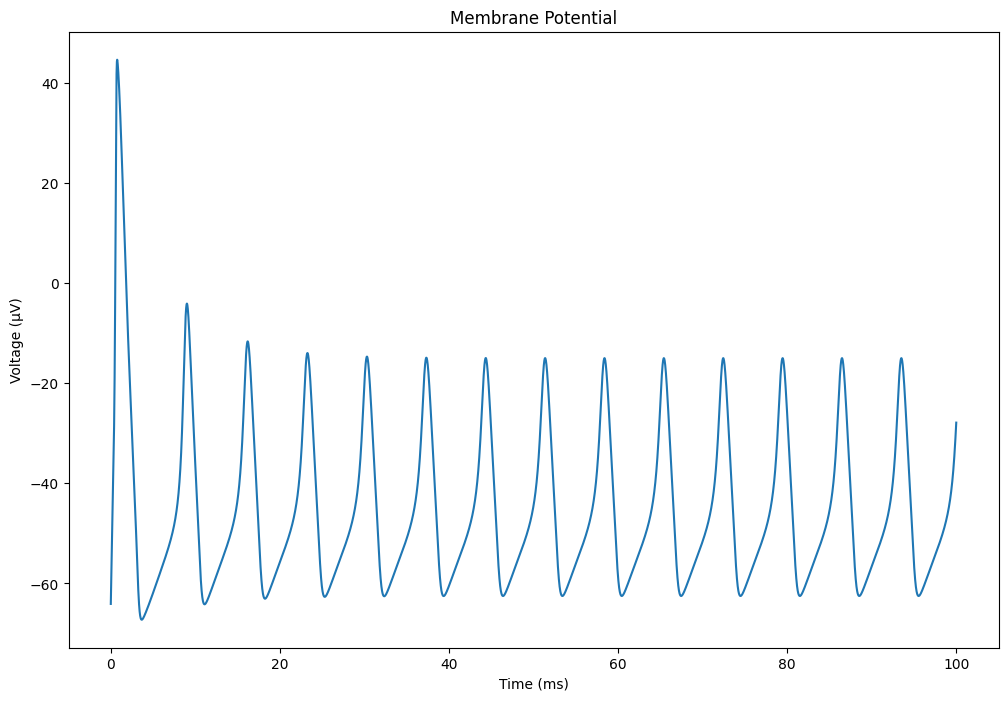

In [8]:
fig1 = plt.figure(figsize=(12, 8))
ax1 = plt.axes()

ax1.plot(t_range, v_hist)
ax1.set_title("Membrane Potential")
ax1.set_xlabel("Time (ms)")
ax1.set_ylabel("Voltage (μV)");

Text(0, 0.5, 'Gate state')

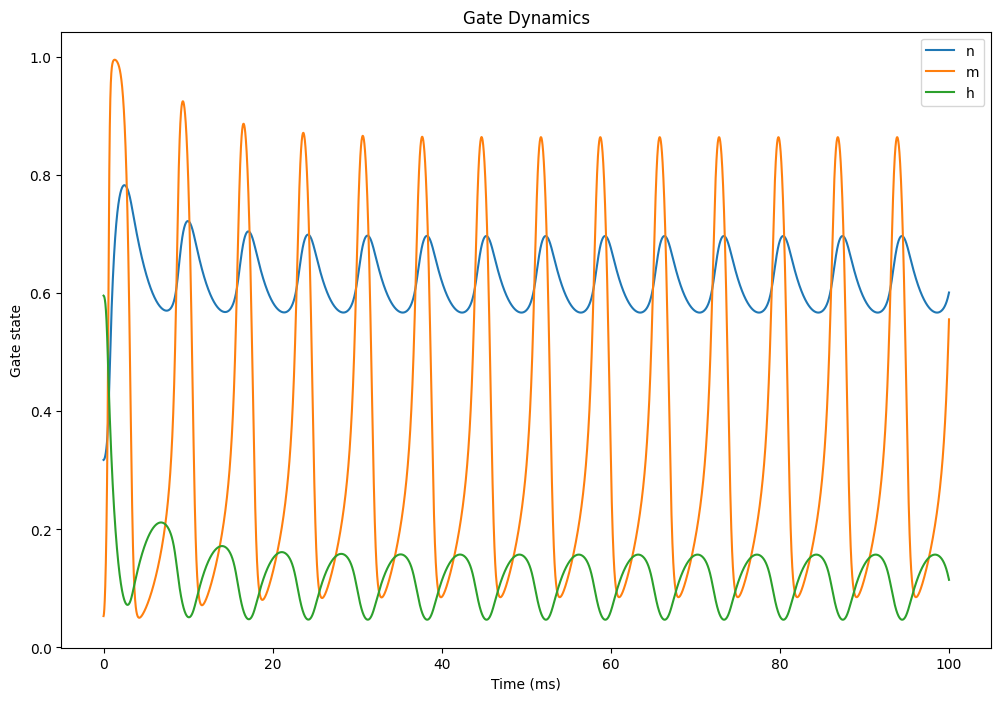

In [9]:
fig2 = plt.figure(figsize=(12, 8))
ax2 = plt.axes()

# TODO: Colour-blind accessibility
ax2.plot(t_range, n_hist, label="n")
ax2.plot(t_range, m_hist, label="m")
ax2.plot(t_range, h_hist, label="h")
ax2.legend()
ax2.set_title("Gate Dynamics")
ax2.set_xlabel("Time (ms)")
ax2.set_ylabel("Gate state")

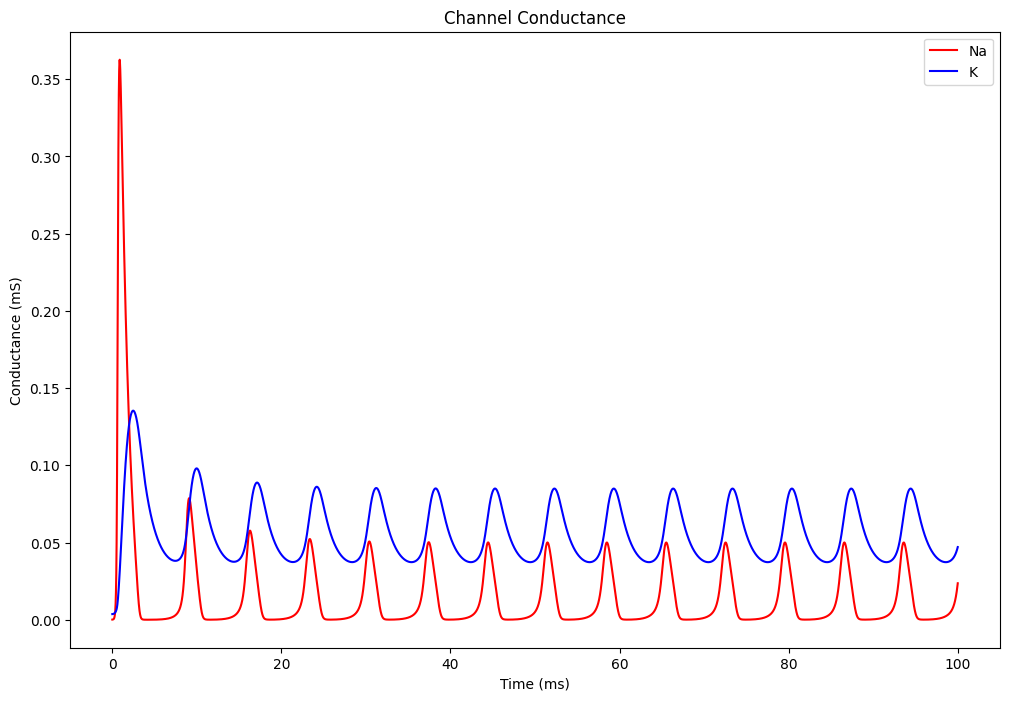

In [10]:
g_na_hist = g_max_na * np.multiply(np.power(m_hist, 3), h_hist)
g_k_hist = g_max_k * np.power(n_hist, 4)

fig3 = plt.figure(figsize=(12, 8))
ax3 = plt.axes()

ax3.plot(t_range, g_na_hist, "r", label="Na")
ax3.plot(t_range, g_k_hist, "b", label="K")
ax3.legend()
ax3.set_title("Channel Conductance")
ax3.set_xlabel("Time (ms)")
ax3.set_ylabel("Conductance (mS)")
plt.show()